<a href="https://colab.research.google.com/github/GautamRawat26/chardham_AI_Assistant/blob/main/Final_project_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Code**

# Updation
```
STEP 0: LOAD DATA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("/content/chardham_Model_Dataset.csv")

# Target
y = df['risk_label_model']

# Features (important ones from your dictionary)
features = [
    'daily_count','temp','rain','wind','humidity',
    'weather_severity','crowd_level_num','is_weekend',
    'lag_1','lag_3','lag_7','rolling_mean_7',
    'trend','crowd_weather_interaction',
    'weekend_crowd_interaction','temple_pressure'
]

X = df[features]

# **1: EDGE vs CLOUD REAL SIMULATION**
```
STEP 1: TRAIN MODEL

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import time

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

```
STEP 2: SIMULATE EDGE vs CLOUD LATENCY

In [ ]:
import time

def simulate_latency(model, X_test, artificial_delay=0):
    start = time.time()

    for i in range(len(X_test)):
        _ = model.predict(X_test.iloc[[i]])
        time.sleep(artificial_delay)  # simulate network delay

    end = time.time()
    return (end - start) / len(X_test)

# Edge = no delay
edge_latency = simulate_latency(model, X_test, artificial_delay=0)

# Cloud = network delay simulation
cloud_latency_50 = simulate_latency(model, X_test, artificial_delay=0.05)
cloud_latency_100 = simulate_latency(model, X_test, artificial_delay=0.1)

print("Edge Latency:", edge_latency)
print("Cloud 50ms:", cloud_latency_50)
print("Cloud 100ms:", cloud_latency_100)

Edge Latency: 0.008809042402676173
Cloud 50ms: 0.05916873982974461
Cloud 100ms: 0.1092760899237224


```
STEP 3: PLOT LATENCY GRAPH

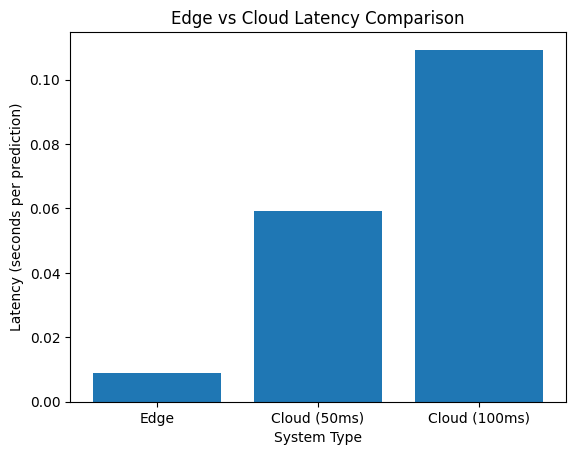

In [ ]:
labels = ['Edge', 'Cloud (50ms)', 'Cloud (100ms)']
values = [edge_latency, cloud_latency_50, cloud_latency_100]

plt.figure()
plt.bar(labels, values)
plt.xlabel("System Type")
plt.ylabel("Latency (seconds per prediction)")
plt.title("Edge vs Cloud Latency Comparison")
plt.savefig("latency.png", dpi=300)
plt.show()

# **2: ROBUSTNESS / NOISE TEST**

```
STEP 1: ADD NOISE FUNCTION

In [ ]:
def add_noise(X, noise_level=0.1):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

```
STEP 2: TEST ROBUSTNESS

In [ ]:
from sklearn.metrics import accuracy_score

noise_levels = [0, 0.1, 0.2, 0.3]
accuracies = []

for noise in noise_levels:
    X_noisy = add_noise(X_test, noise)
    y_pred = model.predict(X_noisy)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

print(accuracies)

[0.9428571428571428, 0.8839285714285714, 0.8303571428571429, 0.7392857142857143]


```
STEP 3: PLOT ROBUSTNESS GRAPH


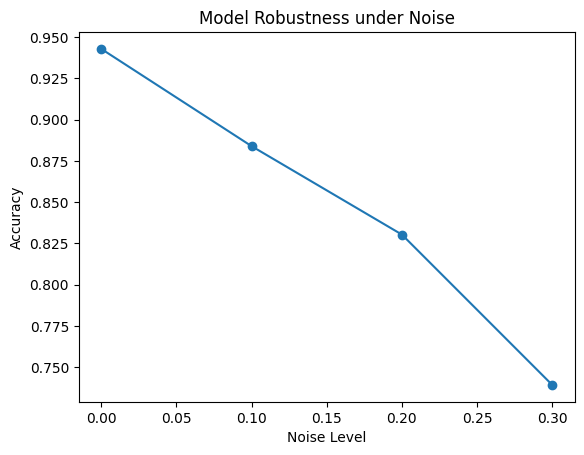

In [ ]:
plt.figure()
plt.plot(noise_levels, accuracies, marker='o')
plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.title("Model Robustness under Noise")
plt.savefig("robustness.png")
plt.show()

# For better figures and grapphs



```
SETUP (COMMON FOR ALL GRAPHS)
```



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Style for publication
plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (6,4),
    "axes.grid": True
})

# Load dataset
df = pd.read_csv("/content/chardham_Model_Dataset.csv")

# Target
y = df['risk_label_model']

# Features (aligned with your data dictionary)
features = [
    'daily_count','temp','rain','wind','humidity',
    'weather_severity','crowd_level_num','is_weekend',
    'lag_1','lag_3','lag_7','rolling_mean_7',
    'trend','crowd_weather_interaction',
    'weekend_crowd_interaction','temple_pressure'
]

X = df[features]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model
model = RandomForestClassifier(n_estimators=200, max_depth=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



```
2. FEATURE IMPORTANCE
```



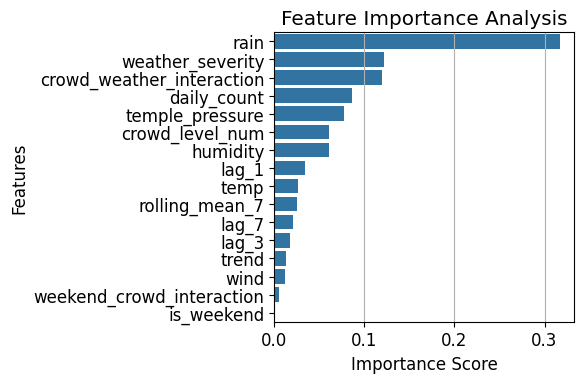

In [ ]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
sns.barplot(
    x=importances[indices],
    y=np.array(features)[indices],
)

plt.title("Feature Importance Analysis")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()



```
CONFUSION MATRIX (HEATMAP)
```



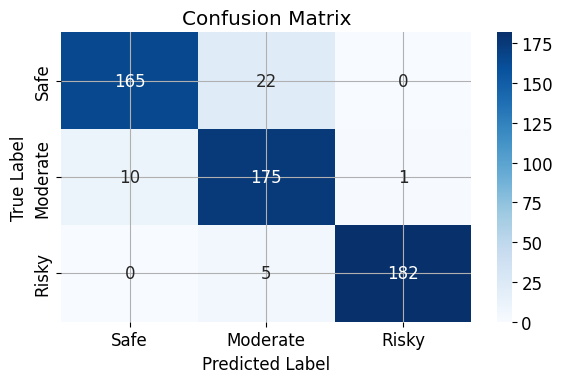

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Safe','Moderate','Risky'],
    yticklabels=['Safe','Moderate','Risky']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("conf_matrix.png", dpi=300)
plt.show()



```
ROC CURVE (MULTI-CLASS)
```



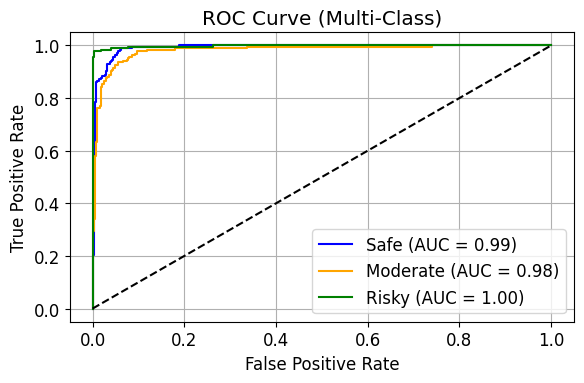

In [ ]:
# Binarize labels (for multi-class ROC)
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure()

colors = ['blue', 'orange', 'green']
labels = ['Safe','Moderate','Risky']

for i in range(3):
    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

# **SHAP EXPLAINABILITY**
```
GENERATE SHAP (TREE MODEL)

In [ ]:
import shap

# Create explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

`
SUMMARY PLOT (MAIN FIGURE)`

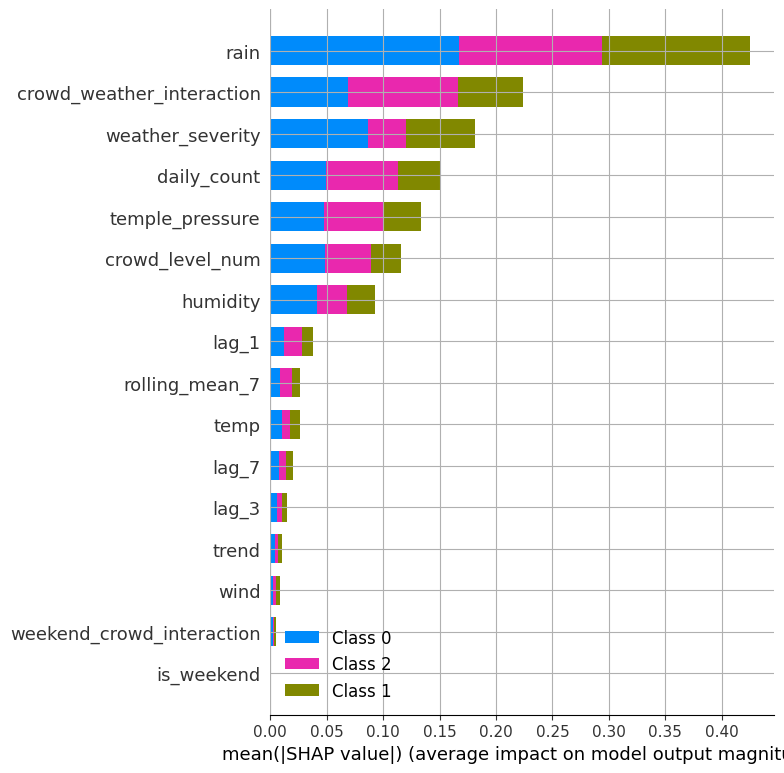

In [ ]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.show()

`DOT PLOT`

<Figure size 600x400 with 0 Axes>

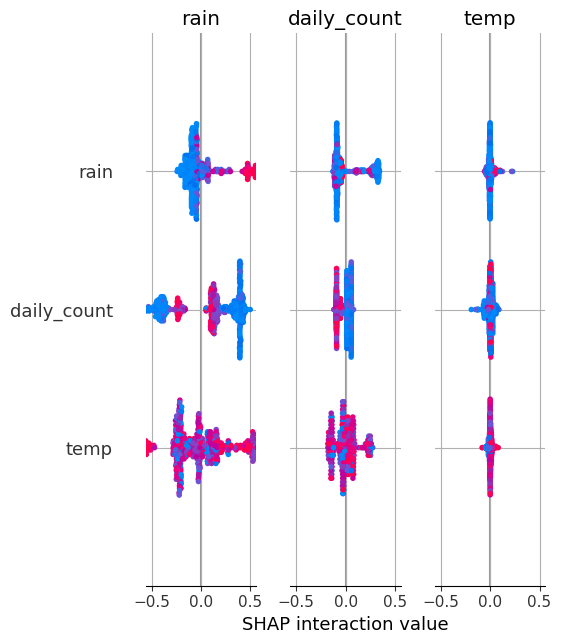

In [ ]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig("shap_detailed.png", dpi=300)
plt.show()

`ABLATION SETUPS`

In [ ]:
from sklearn.metrics import accuracy_score

def evaluate_model(X_mod):
    X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
        X_mod, y, test_size=0.2, random_state=42, stratify=y
    )

    m = RandomForestClassifier(n_estimators=100)
    m.fit(X_train_m, y_train_m)

    y_pred_m = m.predict(X_test_m)
    return accuracy_score(y_test_m, y_pred_m)

`RUN ABLATION`

In [ ]:
results = {}

# Full model
results['Full Model'] = evaluate_model(X)

# Remove interaction features
X_no_interaction = X.drop(columns=[
    'crowd_weather_interaction',
    'weekend_crowd_interaction'
])
results['No Interaction'] = evaluate_model(X_no_interaction)

# Remove temporal features
X_no_temporal = X.drop(columns=[
    'lag_1','lag_3','lag_7','rolling_mean_7','trend'
])
results['No Temporal'] = evaluate_model(X_no_temporal)

# Remove weather features
X_no_weather = X.drop(columns=[
    'weather_severity','rain','temp','humidity','wind'
])
results['No Weather'] = evaluate_model(X_no_weather)

print(results)

{'Full Model': 0.9303571428571429, 'No Interaction': 0.9410714285714286, 'No Temporal': 0.9375, 'No Weather': 0.6446428571428572}




`
PLOT ABLATION GRAPH`



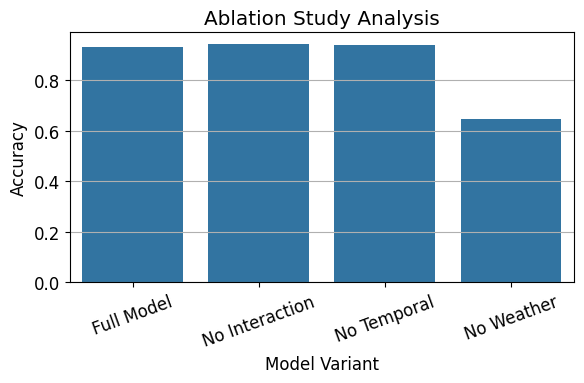

In [ ]:
labels = list(results.keys())
values = list(results.values())

plt.figure()

sns.barplot(x=labels, y=values)

plt.ylabel("Accuracy")
plt.xlabel("Model Variant")
plt.title("Ablation Study Analysis")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("ablation.png", dpi=300)
plt.show()

# **CROSS-DATASET VALIDATION**






`
CREATE SECOND DATASET (DOMAIN SHIFT)`



In [ ]:
import copy

df_new = df.copy()

# Simulate distribution shift
df_new['daily_count'] = df_new['daily_count'] * np.random.uniform(0.7, 1.3, len(df_new))
df_new['weather_severity'] = df_new['weather_severity'] * np.random.uniform(0.8, 1.5, len(df_new))

# Recompute dependent features
df_new['crowd_level_num'] = pd.qcut(df_new['daily_count'], 3, labels=[0,1,2]).astype(int)

df_new['crowd_weather_interaction'] = df_new['crowd_level_num'] * df_new['weather_severity']
df_new['weekend_crowd_interaction'] = df_new['is_weekend'] * (df_new['daily_count'] / 1000)

X_new = df_new[features]
y_new = df_new['risk_label_model']



`
TRAIN ON ORIGINAL, TEST ON NEW
`



In [ ]:
model = RandomForestClassifier(n_estimators=200, max_depth=10)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

y_pred_new = model.predict(X_new)
cross_acc = accuracy_score(y_new, y_pred_new)

print("Cross-Dataset Accuracy:", cross_acc)

Cross-Dataset Accuracy: 0.6825


`
PLOT RESULT`



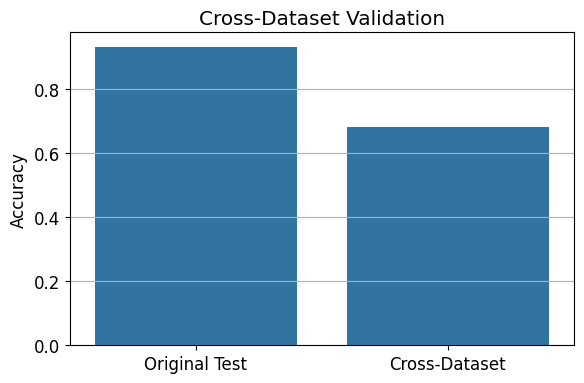

In [ ]:
labels = ['Original Test', 'Cross-Dataset']
values = [
    accuracy_score(y_test, y_pred),
    cross_acc
]

plt.figure()
sns.barplot(x=labels, y=values)

plt.ylabel("Accuracy")
plt.title("Cross-Dataset Validation")

plt.tight_layout()
plt.savefig("cross_dataset.png", dpi=300)
plt.show()

# **GENERALIZATION EXPERIMENT (UNSEEN SCENARIOS)**



`
SPLIT BY SHRINE`



In [ ]:
# Example: train on 3 shrines, test on 1
train_df = df[df['shrine_num'] != 3]   # Yamunotri unseen
test_df = df[df['shrine_num'] == 3]

X_train_g = train_df[features]
y_train_g = train_df['risk_label_model']

X_test_g = test_df[features]
y_test_g = test_df['risk_label_model']



`
TRAIN + TEST`


In [ ]:
model_g = RandomForestClassifier(n_estimators=200)
model_g.fit(X_train_g, y_train_g)

y_pred_g = model_g.predict(X_test_g)

gen_acc = accuracy_score(y_test_g, y_pred_g)

print("Generalization Accuracy:", gen_acc)

Generalization Accuracy: 0.91


`
PLOT`



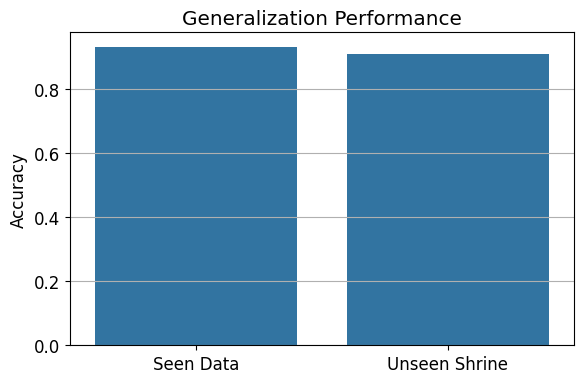

In [ ]:
labels = ['Seen Data', 'Unseen Shrine']
values = [
    accuracy_score(y_test, y_pred),
    gen_acc
]

plt.figure()
sns.barplot(x=labels, y=values)

plt.ylabel("Accuracy")
plt.title("Generalization Performance")

plt.tight_layout()
plt.savefig("generalization.png", dpi=300)
plt.show()

# **XGBOOST**

In [ ]:
# =========================
# BLOCK 1: LOAD AND PREPARE DATA
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("/content/chardham_Model_Dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert date column
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

# Remove rows where date is invalid
df = df.dropna(subset=["date"]).copy()

# Sort properly for time-based modeling
df = df.sort_values(["shrine", "date"]).reset_index(drop=True)

# Keep only yatra season months
df = df[df["date"].dt.month.isin([5, 6, 7, 8, 9, 10])].copy()

# Create month column from date if needed
df["month"] = df["date"].dt.month

# Create day_of_week and is_weekend
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

# Create day_type_num
df["day_type_num"] = df["is_weekend"]

# Required columns for crowd model
required_cols = [
    "date", "shrine", "daily_count",
    "temp", "rain", "wind", "humidity",
    "weather_cat_num", "rain_intensity_num",
    "weather_severity", "heavy_rain_flag", "storm_flag",
    "day_of_week", "is_weekend", "month",
    "seasonal_factor", "day_type_num",
    "shrine_num", "darshan_duration", "peak_hour_flag"
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Dataset shape after cleaning:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape after cleaning: (2800, 33)

First 5 rows:
        date        Day     shrine  daily_count  weather_cat_num  \
0 2022-05-02     Monday  Badrinath       7920.0                0   
1 2022-05-03    Tuesday  Badrinath       8580.0                1   
2 2022-05-04  Wednesday  Badrinath       9240.0                1   
3 2022-05-05   Thursday  Badrinath       9900.0                1   
4 2022-05-06     Friday  Badrinath      10560.0                1   

   rain_intensity_num  crowd_level_num      temp      rain      wind  ...  \
0                   0                0  6.020833  0.000000  3.825000  ...   
1                   1                1  7.470833  0.037500  3.770833  ...   
2                   1                1  6.970833  0.120833  3.233333  ...   
3                   2                1  6.033333  0.337500  3.387500  ...   
4                   1                1  5.441667  0.154167  3.329167  ...   

   peak_hour_flag  shrine_num   trend  crowd_weather_interaction  \
0   

In [ ]:
# =========================
# BLOCK 2: CREATE LAG + TREND FEATURES
# =========================

# Group by shrine (VERY IMPORTANT)
group_col = "shrine"

# Lag features
df["lag_1"] = df.groupby(group_col)["daily_count"].shift(1)
df["lag_3"] = df.groupby(group_col)["daily_count"].shift(3)
df["lag_7"] = df.groupby(group_col)["daily_count"].shift(7)

# Rolling mean (past 7 days)
df["rolling_mean_7"] = (
    df.groupby(group_col)["daily_count"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

# Trend (KEEP THIS SAME EVERYWHERE)
df["trend"] = df["lag_1"] - df["lag_3"]

# Drop rows with missing lag values
df = df.dropna(subset=[
    "lag_1", "lag_3", "lag_7", "rolling_mean_7", "trend"
]).reset_index(drop=True)

print("After lag creation shape:", df.shape)
print(df[["daily_count", "lag_1", "lag_3", "lag_7", "rolling_mean_7", "trend"]].head())

After lag creation shape: (2772, 33)
   daily_count    lag_1    lag_3    lag_7  rolling_mean_7    trend
0      19034.4   8580.0  10560.0   7920.0     9428.571429  -1980.0
1      20620.6  19034.4  11220.0   8580.0    11016.342857   7814.4
2      22206.8  20620.6   8580.0   9240.0    12736.428571  12040.6
3      23793.0  22206.8  19034.4   9900.0    14588.828571   3172.4
4      25379.2  23793.0  20620.6  10560.0    16573.542857   3172.4


In [ ]:
# =========================
# BLOCK 3: FEATURE SELECTION + TIME-BASED SPLIT
# =========================

features = [
    "temp",
    "rain",
    "wind",
    "humidity",
    "weather_cat_num",
    "rain_intensity_num",
    "weather_severity",
    "heavy_rain_flag",
    "storm_flag",
    "day_of_week",
    "is_weekend",
    "month",
    "seasonal_factor",
    "day_type_num",
    "shrine_num",
    "darshan_duration",
    "peak_hour_flag",
    "lag_1",
    "lag_3",
    "lag_7",
    "rolling_mean_7",
    "trend"
]

target = "daily_count"

# Keep only rows needed for modeling
model_df = df[features + [target, "date", "shrine"]].dropna().reset_index(drop=True)

print("Model dataset shape:", model_df.shape)

# Train on early season, test on later season
train_df = model_df[model_df["month"].isin([5, 6, 7])].copy()
test_df  = model_df[model_df["month"].isin([8, 9, 10])].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTrain months:", sorted(train_df["month"].unique()))
print("Test months :", sorted(test_df["month"].unique()))

Model dataset shape: (2772, 25)
X_train shape: (1404, 22)
X_test shape : (1368, 22)
y_train shape: (1404,)
y_test shape : (1368,)

Train months: [np.int32(5), np.int32(6), np.int32(7)]
Test months : [np.int32(8), np.int32(9), np.int32(10)]


In [ ]:
# =========================
# BLOCK 4: TRAIN XGBOOST MODEL
# =========================

from xgboost import XGBRegressor

# Define model
model = XGBRegressor(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
model.fit(X_train, y_train)

print("✅ XGBoost model trained successfully")

✅ XGBoost model trained successfully


In [ ]:
# =========================
# BLOCK 5: PREDICTION + EVALUATION
# =========================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------
# 1. Predict
# -------------------------
y_pred = model.predict(X_test)

# Avoid negative predictions
y_pred = np.maximum(y_pred, 0)

# -------------------------
# 2. Metrics
# -------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# WMAPE (BEST for your project)
y_true = y_test.values
wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100
accuracy = 100 - wmape

print("\n===== CROWD MODEL RESULTS =====")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)
print("WMAPE (%):", wmape)
print("Approx Accuracy (%):", accuracy)


===== CROWD MODEL RESULTS =====
MAE : 820.927983784815
RMSE: 1228.2464588965593
R²  : 0.8426801164394352
WMAPE (%): 18.985512554599275
Approx Accuracy (%): 81.01448744540073


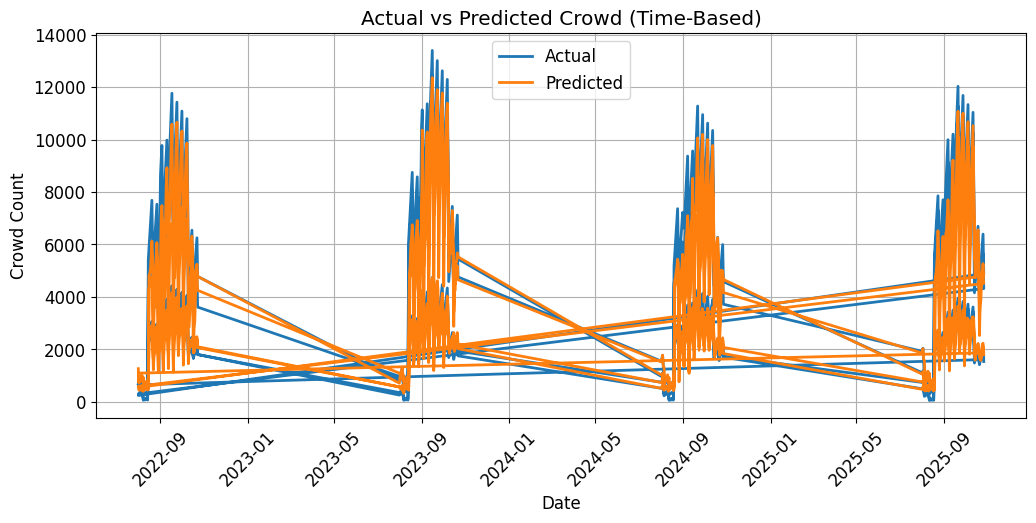

In [ ]:
# =========================
# BLOCK 6: VISUALIZATION
# =========================

import matplotlib.pyplot as plt

# -------------------------
# 1. LINE PLOT (BEST FOR VIVA)
# -------------------------
plt.figure(figsize=(12,5))

plt.plot(test_df["date"], y_test.values, label="Actual", linewidth=2)
plt.plot(test_df["date"], y_pred, label="Predicted", linewidth=2)

plt.title("Actual vs Predicted Crowd (Time-Based)")
plt.xlabel("Date")
plt.ylabel("Crowd Count")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()



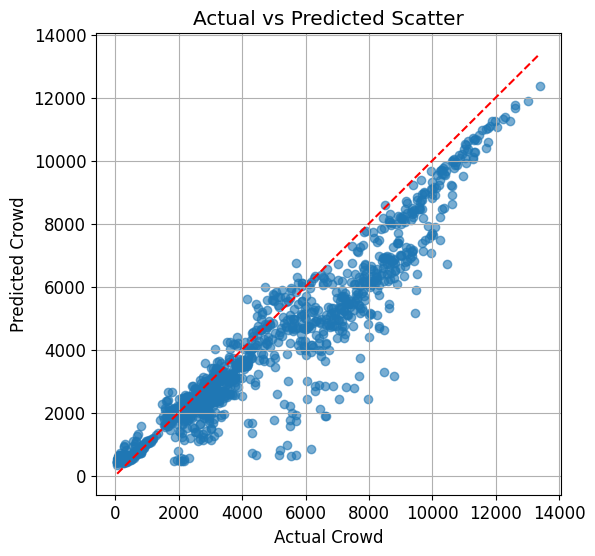

In [ ]:
# -------------------------
# 2. SCATTER PLOT
# -------------------------
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.title("Actual vs Predicted Scatter")
plt.xlabel("Actual Crowd")
plt.ylabel("Predicted Crowd")

plt.grid(True)

plt.show()



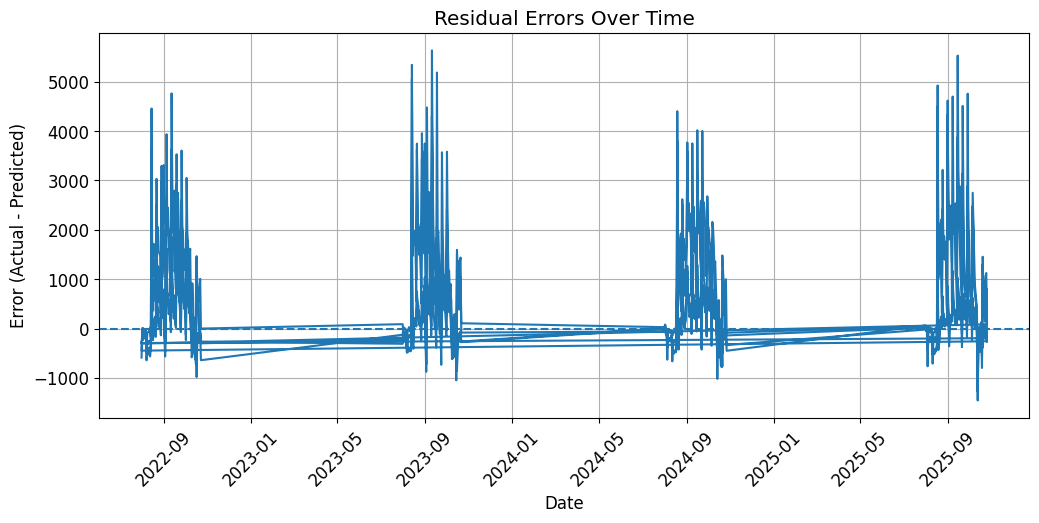

In [ ]:
# -------------------------
# 3. RESIDUAL PLOT
# -------------------------
residuals = y_test.values - y_pred

plt.figure(figsize=(12,5))

plt.plot(test_df["date"], residuals)

plt.axhline(0, linestyle='--')

plt.title("Residual Errors Over Time")
plt.xlabel("Date")
plt.ylabel("Error (Actual - Predicted)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
# =========================
# BLOCK 7: RECURSIVE FUTURE CROWD PREDICTION
# =========================

def crowd_level_from_count(x):
    if x <= 8000:
        return 0
    elif x <= 11000:
        return 1
    else:
        return 2

def predict_future_crowd_recursive(df, model, shrine_name, future_weather_df):
    """
    df               -> historical dataframe after Block 2
    model            -> trained XGBoost model
    shrine_name      -> e.g. 'Kedarnath'
    future_weather_df-> future weather rows for one shrine, already converted to model features
    """

    shrine_hist = df[df["shrine"] == shrine_name].copy()
    shrine_hist = shrine_hist.sort_values("date").reset_index(drop=True)

    known_counts = list(shrine_hist["daily_count"].dropna().values)

    if len(known_counts) < 7:
        raise ValueError(f"Need at least 7 historical rows for {shrine_name}")

    output_rows = []

    for i in range(len(future_weather_df)):
        row = future_weather_df.iloc[i].copy()

        # Build lag features from latest known/predicted crowd values
        lag_1 = known_counts[-1]
        lag_3 = known_counts[-3]
        lag_7 = known_counts[-7]
        rolling_mean_7 = np.mean(known_counts[-7:])
        trend = lag_1 - lag_3   # keep same as training

        row["lag_1"] = lag_1
        row["lag_3"] = lag_3
        row["lag_7"] = lag_7
        row["rolling_mean_7"] = rolling_mean_7
        row["trend"] = trend

        # Same exact feature list used in Block 3
        X_one = pd.DataFrame([row])[features]

        pred_crowd = model.predict(X_one)[0]
        pred_crowd = max(pred_crowd, 0)

        row["daily_count"] = pred_crowd
        row["crowd_level_num"] = crowd_level_from_count(pred_crowd)
        row["temple_pressure"] = pred_crowd / 1000.0
        row["crowd_weather_interaction"] = row["crowd_level_num"] * row["weather_severity"]
        row["weekend_crowd_interaction"] = row["is_weekend"] * row["temple_pressure"]

        known_counts.append(pred_crowd)
        output_rows.append(row)

    return pd.DataFrame(output_rows)

print("✅ Recursive future crowd prediction function ready")

✅ Recursive future crowd prediction function ready


In [ ]:
# =========================
# BLOCK 8: PREPARE FUTURE WEATHER FEATURES
# =========================

def map_weather_cat(code):
    if pd.isna(code):
        return np.nan

    code = int(code)

    clear_codes = {1000, 1100, 1101}
    moderate_codes = {1001, 1102, 2000, 2100, 4000, 4001, 4200, 4201}
    severe_codes = {5000, 5001, 5100, 5101, 6000, 6001, 6200, 6201, 7000, 7101, 7102, 8000}

    if code in clear_codes:
        return 0
    elif code in moderate_codes:
        return 1
    elif code in severe_codes:
        return 2
    else:
        return 1

def map_rain_intensity_num(x):
    if pd.isna(x):
        return np.nan

    x = float(x)

    if x == 0:
        return 0
    elif x < 0.2:
        return 1
    elif x < 0.6:
        return 2
    else:
        return 3

def seasonal_factor_from_month(month):
    if month in [5, 6]:
        return 1.1
    elif month in [7, 8]:
        return 0.8
    else:
        return 1.0

def prepare_future_weather_features(future_weather_df, shrine_map):
    temp_df = future_weather_df.copy()

    temp_df["date"] = pd.to_datetime(temp_df["date"], errors="coerce")
    temp_df = temp_df.dropna(subset=["date"]).copy()

    temp_df["month"] = temp_df["date"].dt.month
    temp_df["day_of_week"] = temp_df["date"].dt.dayofweek
    temp_df["is_weekend"] = temp_df["day_of_week"].isin([5, 6]).astype(int)
    temp_df["day_type_num"] = temp_df["is_weekend"]

    temp_df["temp"] = temp_df["temp_avg"]
    temp_df["rain"] = temp_df["rain_intensity_max"]
    temp_df["wind"] = temp_df["wind_speed_avg"]
    temp_df["humidity"] = temp_df["humidity_avg"]

    temp_df["weather_cat_num"] = temp_df["weather_code_max"].apply(map_weather_cat)
    temp_df["rain_intensity_num"] = temp_df["rain_intensity_max"].apply(map_rain_intensity_num)

    temp_df["heavy_rain_flag"] = (temp_df["rain_intensity_num"] >= 3).astype(int)
    temp_df["storm_flag"] = (temp_df["weather_cat_num"] == 2).astype(int)

    temp_df["seasonal_factor"] = temp_df["month"].apply(seasonal_factor_from_month)
    temp_df["shrine_num"] = temp_df["shrine"].map(shrine_map)

    # simple temple logic
    temp_df["darshan_duration"] = np.where(temp_df["is_weekend"] == 1, 60, 30)
    temp_df["peak_hour_flag"] = np.where(temp_df["is_weekend"] == 1, 1, 0)

    # keep same weather severity logic as training data
    temp_df["weather_severity"] = (
        (temp_df["temp"] * 1.0) +
        (temp_df["rain"] * 2.0) +
        (temp_df["wind"] * 1.5) +
        (temp_df["humidity"] * 0.1)
    )

    return temp_df

# Example shrine mapping
shrine_map = {
    "Kedarnath": 0,
    "Badrinath": 1,
    "Gangotri": 2,
    "Yamunotri": 3
}

print("✅ Future weather feature preparation function ready")

✅ Future weather feature preparation function ready


In [ ]:
# =========================
# BLOCK 9: FETCH FUTURE WEATHER
# =========================

import requests
import pandas as pd

API_KEY = "2QOz3R4rQJvO6lWHExFkOAUdJ3mgJsvv"

DHAM_COORDS = {
    "Kedarnath": "30.7346,79.0669",
    "Badrinath": "30.7433,79.4938",
    "Gangotri":  "30.9947,78.9398",
    "Yamunotri": "31.0140,78.4600"
}

def fetch_future_weather_for_dham(dham_name, location, api_key, future_days=7):
    url = "https://api.tomorrow.io/v4/weather/forecast"

    params = {
        "location": location,
        "timesteps": ["1d"],
        "units": "metric",
        "apikey": api_key
    }

    headers = {"accept": "application/json"}

    response = requests.get(url, params=params, headers=headers, timeout=30)
    print(f"{dham_name} -> Status Code: {response.status_code}")

    data = response.json()

    if "timelines" not in data:
        raise ValueError(f"Tomorrow.io error for {dham_name}: {data}")

    daily_intervals = data["timelines"]["daily"][:future_days]

    rows = []
    for row in daily_intervals:
        values = row["values"]

        rows.append({
            "shrine": dham_name,
            "date": row["time"][:10],
            "temp_avg": values.get("temperatureAvg"),
            "humidity_avg": values.get("humidityAvg"),
            "wind_speed_avg": values.get("windSpeedAvg"),
            "rain_intensity_max": values.get("rainIntensityMax"),
            "precip_prob_max": values.get("precipitationProbabilityMax"),
            "weather_code_max": values.get("weatherCodeMax")
        })

    return pd.DataFrame(rows)

# Example: fetch for one shrine
future_weather_df = fetch_future_weather_for_dham(
    dham_name="Kedarnath",
    location=DHAM_COORDS["Kedarnath"],
    api_key=API_KEY,
    future_days=7
)

print(future_weather_df.head())

Kedarnath -> Status Code: 200
      shrine        date  temp_avg  humidity_avg  wind_speed_avg  \
0  Kedarnath  2026-06-23      7.63            69             0.6   
1  Kedarnath  2026-06-24      8.64            66             0.7   
2  Kedarnath  2026-06-25      8.96            66             0.7   
3  Kedarnath  2026-06-26      8.04            66             1.0   
4  Kedarnath  2026-06-27      9.19            63             1.0   

   rain_intensity_max  precip_prob_max  weather_code_max  
0                0.42               20              5001  
1                0.23               20              2000  
2                0.38               25              2000  
3                0.39               30              2000  
4                0.11               25              2000  


In [ ]:
# =========================
# BLOCK 10: PREPARE FEATURES + PREDICT FUTURE CROWD
# =========================

# 1. Convert raw weather to model-ready features
future_features_df = prepare_future_weather_features(future_weather_df, shrine_map)

print("Future feature rows:")
print(future_features_df.head())

# 2. Predict recursively for one shrine
future_crowd_pred_df = predict_future_crowd_recursive(
    df=df,                      # historical dataframe from Block 2
    model=model,                # trained XGBoost model from Block 4
    shrine_name="Kedarnath",    # change as needed
    future_weather_df=future_features_df
)

# 3. Show result
print("\n===== FUTURE CROWD PREDICTION =====")
print(future_crowd_pred_df[[
    "date",
    "shrine",
    "temp",
    "rain",
    "wind",
    "humidity",
    "daily_count",
    "crowd_level_num",
    "temple_pressure"
]])

Future feature rows:
      shrine       date  temp_avg  humidity_avg  wind_speed_avg  \
0  Kedarnath 2026-06-23      7.63            69             0.6   
1  Kedarnath 2026-06-24      8.64            66             0.7   
2  Kedarnath 2026-06-25      8.96            66             0.7   
3  Kedarnath 2026-06-26      8.04            66             1.0   
4  Kedarnath 2026-06-27      9.19            63             1.0   

   rain_intensity_max  precip_prob_max  weather_code_max  month  day_of_week  \
0                0.42               20              5001      6            1   
1                0.23               20              2000      6            2   
2                0.38               25              2000      6            3   
3                0.39               30              2000      6            4   
4                0.11               25              2000      6            5   

   ...  humidity  weather_cat_num  rain_intensity_num  heavy_rain_flag  \
0  ...        69     

In [ ]:
# =========================
# BLOCK 11: TRAIN RISK MODEL
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------
# 1. Helper function
# -------------------------
def crowd_level_from_count(x):
    if x <= 8000:
        return 0
    elif x <= 11000:
        return 1
    else:
        return 2

# -------------------------
# 2. Rebuild crowd-based features
# -------------------------
# The original 'df' (from kernel state, after lag features in Block 2)
# contains 'risk_label_model' and all necessary features for the risk model.
# The 'train_df' and 'test_df' used previously were missing the 'risk_label_model'
# due to an intermediate selection for the crowd model.
# We re-create 'train_risk_df' and 'test_risk_df' from the comprehensive 'df'
# using the same time-based split months as defined in Block 3.
train_risk_df = df[df["month"].isin([5, 6, 7])].copy()
test_risk_df  = df[df["month"].isin([8, 9, 10])].copy()

# In training period, use actual crowd
train_risk_df["predicted_crowd"] = train_risk_df["daily_count"]

# In test period, use crowd model predictions (y_pred is from Block 5)
test_risk_df["predicted_crowd"] = y_pred

# Crowd level
train_risk_df["predicted_crowd_level"] = train_risk_df["predicted_crowd"].apply(crowd_level_from_count)
test_risk_df["predicted_crowd_level"] = test_risk_df["predicted_crowd"].apply(crowd_level_from_count)

# Rebuild interactions from predicted crowd
train_risk_df["predicted_temple_pressure"] = train_risk_df["predicted_crowd"] / 1000.0
test_risk_df["predicted_temple_pressure"] = test_risk_df["predicted_crowd"] / 1000.0

train_risk_df["predicted_crowd_weather_interaction"] = (
    train_risk_df["predicted_crowd_level"] * train_risk_df["weather_severity"]
)
test_risk_df["predicted_crowd_weather_interaction"] = (
    test_risk_df["predicted_crowd_level"] * test_risk_df["weather_severity"]
)

train_risk_df["predicted_weekend_crowd_interaction"] = (
    train_risk_df["is_weekend"] * train_risk_df["predicted_temple_pressure"]
)
test_risk_df["predicted_weekend_crowd_interaction"] = (
    test_risk_df["is_weekend"] * test_risk_df["predicted_temple_pressure"]
)

train_risk_df["predicted_rain_crowd_interaction"] = (
    train_risk_df["rain_intensity_num"] * train_risk_df["predicted_crowd_level"]
)
test_risk_df["predicted_rain_crowd_interaction"] = (
    test_risk_df["rain_intensity_num"] * test_risk_df["predicted_crowd_level"]
)

train_risk_df["predicted_final_risk_signal"] = (
    train_risk_df["predicted_crowd_level"] * train_risk_df["weather_severity"] * (1 + train_risk_df["is_weekend"])
)
test_risk_df["predicted_final_risk_signal"] = (
    test_risk_df["predicted_crowd_level"] * test_risk_df["weather_severity"] * (1 + test_risk_df["is_weekend"])
)

# -------------------------
# 3. Risk model features
# -------------------------
risk_features = [
    "predicted_crowd",
    "predicted_crowd_level",
    "temp",
    "rain",
    "wind",
    "humidity",
    "weather_cat_num",
    "rain_intensity_num",
    "weather_severity",
    "heavy_rain_flag",
    "storm_flag",
    "day_of_week",
    "is_weekend",
    "month",
    "seasonal_factor",
    "day_type_num",
    "shrine_num",
    "darshan_duration",
    "peak_hour_flag",
    "lag_1",
    "lag_3",
    "lag_7",
    "rolling_mean_7",
    "trend",
    "predicted_temple_pressure",
    "predicted_crowd_weather_interaction",
    "predicted_weekend_crowd_interaction",
    "predicted_rain_crowd_interaction",
    "predicted_final_risk_signal"
]

target_cls = "risk_label_model"

X_train_cls = train_risk_df[risk_features]
y_train_cls = train_risk_df[target_cls]

X_test_cls = test_risk_df[risk_features]
y_test_cls = test_risk_df[target_cls]

# -------------------------
# 4. Train Random Forest
# -------------------------
risk_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

risk_model.fit(X_train_cls, y_train_cls)

# -------------------------
# 5. Evaluate
# -------------------------
pred_cls = risk_model.predict(X_test_cls)

acc = accuracy_score(y_test_cls, pred_cls)

print("===== RISK MODEL RESULTS =====")
print("Accuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test_cls, pred_cls))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_cls, pred_cls))

===== RISK MODEL RESULTS =====
Accuracy: 0.8691520467836257

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.97      0.92       660
           1       0.83      0.77      0.80       463
           2       0.98      0.77      0.86       245

    accuracy                           0.87      1368
   macro avg       0.89      0.84      0.86      1368
weighted avg       0.87      0.87      0.87      1368


Confusion Matrix:

[[642  18   0]
 [101 358   4]
 [  0  56 189]]


In [ ]:
# =========================
# BLOCK 12: FUTURE RISK PREDICTION
# =========================

def risk_label_name(x):
    label_map = {
        0: "Safe",
        1: "Moderate",
        2: "Risky"
    }
    return label_map.get(int(x), "Unknown")

# 1. Start from future crowd output
future_risk_df = future_crowd_pred_df.copy()

# 2. Build extra interaction features needed by risk model
future_risk_df["predicted_crowd"] = future_risk_df["daily_count"]
future_risk_df["predicted_crowd_level"] = future_risk_df["predicted_crowd"].apply(crowd_level_from_count)

future_risk_df["predicted_temple_pressure"] = future_risk_df["predicted_crowd"] / 1000.0

future_risk_df["predicted_crowd_weather_interaction"] = (
    future_risk_df["predicted_crowd_level"] * future_risk_df["weather_severity"]
)

future_risk_df["predicted_weekend_crowd_interaction"] = (
    future_risk_df["is_weekend"] * future_risk_df["predicted_temple_pressure"]
)

future_risk_df["predicted_rain_crowd_interaction"] = (
    future_risk_df["rain_intensity_num"] * future_risk_df["predicted_crowd_level"]
)

future_risk_df["predicted_final_risk_signal"] = (
    future_risk_df["predicted_crowd_level"] * future_risk_df["weather_severity"] * (1 + future_risk_df["is_weekend"])
)

# 3. Make sure all risk features exist
for col in risk_features:
    if col not in future_risk_df.columns:
        raise ValueError(f"Missing required future risk feature: {col}")

X_future_risk = future_risk_df[risk_features]

# 4. Predict future risk
future_risk_df["risk_label_model"] = risk_model.predict(X_future_risk)
future_risk_df["risk_label_name"] = future_risk_df["risk_label_model"].apply(risk_label_name)

# 5. Optional probabilities
if hasattr(risk_model, "predict_proba"):
    probs = risk_model.predict_proba(X_future_risk)
    future_risk_df["safe_prob"] = probs[:, 0]
    future_risk_df["moderate_prob"] = probs[:, 1]
    future_risk_df["risky_prob"] = probs[:, 2]

# 6. Show final output
final_cols = [
    "date",
    "shrine",
    "temp",
    "rain",
    "wind",
    "humidity",
    "predicted_crowd",
    "predicted_crowd_level",
    "predicted_temple_pressure",
    "risk_label_model",
    "risk_label_name"
]

extra_prob_cols = [c for c in ["safe_prob", "moderate_prob", "risky_prob"] if c in future_risk_df.columns]
final_cols = final_cols + extra_prob_cols

print("===== FUTURE RISK OUTPUT =====")
print(future_risk_df[final_cols])

===== FUTURE RISK OUTPUT =====
        date     shrine  temp  rain  wind  humidity  predicted_crowd  \
0 2026-06-23  Kedarnath  7.63  0.42   0.6        69      4574.612793   
1 2026-06-24  Kedarnath  8.64  0.23   0.7        66      4309.066406   
2 2026-06-25  Kedarnath  8.96  0.38   0.7        66      4222.103516   
3 2026-06-26  Kedarnath  8.04  0.39   1.0        66      4330.225586   
4 2026-06-27  Kedarnath  9.19  0.11   1.0        63     18174.654297   
5 2026-06-28  Kedarnath  9.47  0.16   0.9        64     22215.425781   

   predicted_crowd_level  predicted_temple_pressure  risk_label_model  \
0                      0                   4.574613                 1   
1                      0                   4.309066                 1   
2                      0                   4.222104                 1   
3                      0                   4.330226                 1   
4                      2                  18.174654                 2   
5                      2  

In [ ]:
# =========================
# BLOCK 13: SAVE FINAL OUTPUT
# =========================

# Clean final table for export
export_cols = [
    "date",
    "shrine",
    "temp",
    "rain",
    "wind",
    "humidity",
    "predicted_crowd",
    "predicted_crowd_level",
    "predicted_temple_pressure",
    "risk_label_model",
    "risk_label_name"
]

prob_cols = [c for c in ["safe_prob", "moderate_prob", "risky_prob"] if c in future_risk_df.columns]
export_cols = export_cols + prob_cols

final_output_df = future_risk_df[export_cols].copy()
final_output_df = final_output_df.sort_values(["shrine", "date"]).reset_index(drop=True)

# Save
final_output_df.to_csv("final_future_prediction_output.csv", index=False)

print("✅ Saved file: final_future_prediction_output.csv")
print("\n===== FINAL OUTPUT TABLE =====")
print(final_output_df)

✅ Saved file: final_future_prediction_output.csv

===== FINAL OUTPUT TABLE =====
        date     shrine  temp  rain  wind  humidity  predicted_crowd  \
0 2026-06-23  Kedarnath  7.63  0.42   0.6        69      4574.612793   
1 2026-06-24  Kedarnath  8.64  0.23   0.7        66      4309.066406   
2 2026-06-25  Kedarnath  8.96  0.38   0.7        66      4222.103516   
3 2026-06-26  Kedarnath  8.04  0.39   1.0        66      4330.225586   
4 2026-06-27  Kedarnath  9.19  0.11   1.0        63     18174.654297   
5 2026-06-28  Kedarnath  9.47  0.16   0.9        64     22215.425781   

   predicted_crowd_level  predicted_temple_pressure  risk_label_model  \
0                      0                   4.574613                 1   
1                      0                   4.309066                 1   
2                      0                   4.222104                 1   
3                      0                   4.330226                 1   
4                      2                  18.1746

In [ ]:
import joblib

joblib.dump(model, "crowd_xgb_model.pkl")
joblib.dump(risk_model, "risk_rf_model.pkl")

['risk_rf_model.pkl']

In [ ]:
# =========================
# BLOCK A: FUTURE GROWTH BASELINE CREATION
# =========================

import pandas as pd
import numpy as np

def build_future_growth_baseline(hist_df, start_year=2026, end_year=2030, annual_growth=200000):
    """
    Build future baseline crowd using:
    1. +2 lakh total growth per year
    2. monthly distribution trend
    3. daily weekday trend
    4. shrine-wise share
    """

    df = hist_df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["date"]).copy()

    # Keep only yatra season
    df = df[df["date"].dt.month.isin([5, 6, 7, 8, 9, 10])].copy()

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    # -------------------------
    # 1. Find latest historical year
    # -------------------------
    latest_year = df["year"].max()
    latest_df = df[df["year"] == latest_year].copy()

    # Total crowd in latest year
    latest_total = latest_df["daily_count"].sum()

    print(f"Latest historical year: {latest_year}")
    print(f"Latest total crowd: {latest_total:,.0f}")

    # -------------------------
    # 2. Shrine share from latest year
    # -------------------------
    shrine_share = (
        latest_df.groupby("shrine")["daily_count"].sum() /
        latest_df["daily_count"].sum()
    ).to_dict()

    print("\nShrine share:")
    print(shrine_share)

    # -------------------------
    # 3. Monthly trend ratio
    # Use average monthly pattern from all years
    # -------------------------
    yearly_month = (
        df.groupby(["year", "month"])["daily_count"].sum()
          .reset_index()
    )

    yearly_total = (
        df.groupby("year")["daily_count"].sum()
          .reset_index()
          .rename(columns={"daily_count": "year_total"})
    )

    yearly_month = yearly_month.merge(yearly_total, on="year", how="left")
    yearly_month["month_ratio"] = yearly_month["daily_count"] / yearly_month["year_total"]

    month_ratio = (
        yearly_month.groupby("month")["month_ratio"].mean()
        .to_dict()
    )

    # Normalize
    month_sum = sum(month_ratio.values())
    month_ratio = {k: v / month_sum for k, v in month_ratio.items()}

    print("\nMonth ratio:")
    print(month_ratio)

    # -------------------------
    # 4. Daily weekday trend within month
    # -------------------------
    month_day = (
        df.groupby(["month", "day_of_week"])["daily_count"].sum()
          .reset_index()
    )

    month_total = (
        df.groupby("month")["daily_count"].sum()
          .reset_index()
          .rename(columns={"daily_count": "month_total"})
    )

    month_day = month_day.merge(month_total, on="month", how="left")
    month_day["dow_ratio"] = month_day["daily_count"] / month_day["month_total"]

    dow_ratio_map = {}
    for m in sorted(df["month"].unique()):
        temp = month_day[month_day["month"] == m].copy()
        ratios = dict(zip(temp["day_of_week"], temp["dow_ratio"]))

        # normalize inside each month
        s = sum(ratios.values())
        ratios = {k: v / s for k, v in ratios.items()}
        dow_ratio_map[m] = ratios

    # -------------------------
    # 5. Build future rows
    # -------------------------
    future_rows = []

    for year in range(start_year, end_year + 1):
        # +2 lakh per year from latest historical total
        year_growth_steps = year - latest_year
        future_total = latest_total + (annual_growth * year_growth_steps)

        for shrine, s_share in shrine_share.items():
            shrine_year_total = future_total * s_share

            for month, m_ratio in month_ratio.items():
                shrine_month_total = shrine_year_total * m_ratio

                # all dates in that month
                month_dates = pd.date_range(
                    start=f"{year}-{month:02d}-01",
                    end=(pd.Timestamp(f"{year}-{month:02d}-01") + pd.offsets.MonthEnd(0)),
                    freq="D"
                )

                # keep only valid season dates
                month_dates = [d for d in month_dates if d.month in [5, 6, 7, 8, 9, 10]]

                # get weekday ratios for this month
                dow_ratio = dow_ratio_map.get(month, {
                    0: 0.13, 1: 0.14, 2: 0.14, 3: 0.15, 4: 0.16, 5: 0.17, 6: 0.11
                })

                # assign raw weekday weights date-wise
                temp_rows = []
                for d in month_dates:
                    dow = d.dayofweek
                    temp_rows.append({
                        "date": d,
                        "year": year,
                        "month": month,
                        "day_of_week": dow,
                        "shrine": shrine,
                        "raw_weight": dow_ratio.get(dow, 1/7)
                    })

                temp_df = pd.DataFrame(temp_rows)

                # normalize within the month
                temp_df["daily_ratio"] = temp_df["raw_weight"] / temp_df["raw_weight"].sum()
                temp_df["baseline_daily_count"] = shrine_month_total * temp_df["daily_ratio"]

                future_rows.append(temp_df)

    future_baseline_df = pd.concat(future_rows, ignore_index=True)

    future_baseline_df["Day"] = future_baseline_df["date"].dt.day_name()
    future_baseline_df["is_weekend"] = future_baseline_df["day_of_week"].isin([5, 6]).astype(int)
    future_baseline_df["day_type_num"] = future_baseline_df["is_weekend"]

    return future_baseline_df

In [ ]:
# =========================
# BLOCK B: GENERATE FUTURE BASELINE
# =========================

future_baseline_df = build_future_growth_baseline(
    hist_df=df,              # your cleaned historical dataframe
    start_year=2026,
    end_year=2030,           # change if needed
    annual_growth=200000
)

print("Future baseline shape:", future_baseline_df.shape)
print(future_baseline_df.head())

Latest historical year: 2025
Latest total crowd: 4,997,783

Shrine share:
{'Badrinath': 0.3459619872220933, 'Gangotri': 0.15458001314422923, 'Kedarnath': 0.36581815303450776, 'Yamunotri': 0.1336398465991698}

Month ratio:
{5: 0.4062634175655098, 6: 0.2560498540923133, 7: 0.038470449208457665, 8: 0.06026672136187653, 9: 0.14711301252253417, 10: 0.09183654524930861}
Future baseline shape: (3680, 11)
        date  year  month  day_of_week     shrine  raw_weight  daily_ratio  \
0 2026-05-01  2026      5            4  Badrinath    0.157858     0.035639   
1 2026-05-02  2026      5            5  Badrinath    0.158134     0.035702   
2 2026-05-03  2026      5            6  Badrinath    0.113302     0.025580   
3 2026-05-04  2026      5            0  Badrinath    0.132397     0.029891   
4 2026-05-05  2026      5            1  Badrinath    0.143430     0.032382   

   baseline_daily_count       Day  is_weekend  day_type_num  
0          26036.675544    Friday           0             0  
1     

In [ ]:
# =========================
# BLOCK C: PREPARE FUTURE BASELINE WITH HISTORICAL WEATHER PROFILE
# =========================

def attach_historical_weather_profile(hist_df, future_baseline_df):
    """
    Attach average weather profile using historical month + shrine + weekday pattern.
    Useful when real future weather is not available for far future years.
    """
    df = hist_df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["date"]).copy()

    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    weather_profile = (
        df.groupby(["shrine", "month", "day_of_week"])[
            ["temp", "rain", "wind", "humidity",
             "weather_cat_num", "rain_intensity_num",
             "weather_severity", "heavy_rain_flag", "storm_flag",
             "seasonal_factor", "darshan_duration", "peak_hour_flag", "shrine_num"]
        ]
        .mean()
        .reset_index()
    )

    merged = future_baseline_df.merge(
        weather_profile,
        on=["shrine", "month", "day_of_week"],
        how="left"
    )

    return merged

In [ ]:
# =========================
# BLOCK D: CREATE MODEL-READY FUTURE DF
# =========================

future_model_df = attach_historical_weather_profile(df, future_baseline_df)

print("Future model df shape:", future_model_df.shape)
print(future_model_df.head())

Future model df shape: (3680, 24)
        date  year  month  day_of_week     shrine  raw_weight  daily_ratio  \
0 2026-05-01  2026      5            4  Badrinath    0.157858     0.035639   
1 2026-05-02  2026      5            5  Badrinath    0.158134     0.035702   
2 2026-05-03  2026      5            6  Badrinath    0.113302     0.025580   
3 2026-05-04  2026      5            0  Badrinath    0.132397     0.029891   
4 2026-05-05  2026      5            1  Badrinath    0.143430     0.032382   

   baseline_daily_count       Day  is_weekend  ...   humidity  \
0          26036.675544    Friday           0  ...  60.719444   
1          26082.250655  Saturday           1  ...  62.098214   
2          18687.744905    Sunday           1  ...  68.435897   
3          21837.222589    Monday           0  ...  68.149510   
4          23656.978067   Tuesday           0  ...  68.629902   

   weather_cat_num  rain_intensity_num  weather_severity  heavy_rain_flag  \
0         0.600000           

In [ ]:
# =========================
# BLOCK E: RECURSIVE FUTURE CROWD PREDICTION WITH GROWTH BASELINE
# =========================

def predict_future_crowd_with_growth(hist_df, model, shrine_name, shrine_future_df, alpha=0.65):
    """
    alpha = model weight
    (1-alpha) = baseline growth weight

    final_prediction = alpha * model_prediction + (1-alpha) * baseline_daily_count
    """

    shrine_hist = hist_df[hist_df["shrine"] == shrine_name].copy()
    shrine_hist = shrine_hist.sort_values("date").reset_index(drop=True)

    known_counts = list(shrine_hist["daily_count"].dropna().values)

    if len(known_counts) < 7:
        raise ValueError(f"Need at least 7 historical rows for {shrine_name}")

    output_rows = []

    for i in range(len(shrine_future_df)):
        row = shrine_future_df.iloc[i].copy()

        lag_1 = known_counts[-1]
        lag_3 = known_counts[-3]
        lag_7 = known_counts[-7]
        rolling_mean_7 = np.mean(known_counts[-7:])
        trend = lag_1 - lag_3

        row["lag_1"] = lag_1
        row["lag_3"] = lag_3
        row["lag_7"] = lag_7
        row["rolling_mean_7"] = rolling_mean_7
        row["trend"] = trend

        # ensure year index
        min_year = hist_df["date"].dt.year.min()
        row["year_index"] = row["year"] - min_year

        # model features
        X_one = pd.DataFrame([row])[features]

        model_pred = model.predict(X_one)[0]
        model_pred = max(model_pred, 0)

        # baseline growth prediction
        baseline_pred = row["baseline_daily_count"]

        # blend both
        final_pred = (alpha * model_pred) + ((1 - alpha) * baseline_pred)
        final_pred = max(final_pred, 0)

        row["model_pred_only"] = model_pred
        row["baseline_pred_only"] = baseline_pred
        row["daily_count"] = final_pred

        row["crowd_level_num"] = crowd_level_from_count(final_pred)
        row["temple_pressure"] = final_pred / 1000.0
        row["crowd_weather_interaction"] = row["crowd_level_num"] * row["weather_severity"]
        row["weekend_crowd_interaction"] = row["is_weekend"] * row["temple_pressure"]

        known_counts.append(final_pred)
        output_rows.append(row)

    return pd.DataFrame(output_rows)

In [ ]:
# =========================
# BLOCK F: RUN FUTURE CROWD PREDICTION FOR ALL SHRINES
# =========================

future_pred_parts = []

for shrine_name in future_model_df["shrine"].unique():
    shrine_future = future_model_df[future_model_df["shrine"] == shrine_name].copy()
    shrine_future = shrine_future.sort_values("date").reset_index(drop=True)

    shrine_pred = predict_future_crowd_with_growth(
        hist_df=df,
        model=model,
        shrine_name=shrine_name,
        shrine_future_df=shrine_future,
        alpha=0.65   # 65% ML + 35% growth baseline
    )

    future_pred_parts.append(shrine_pred)

future_crowd_pred_df = pd.concat(future_pred_parts, ignore_index=True)

print(future_crowd_pred_df[[
    "date", "year", "shrine",
    "baseline_pred_only", "model_pred_only", "daily_count"
]].head(20))

         date  year     shrine  baseline_pred_only  model_pred_only  \
0  2026-05-01  2026  Badrinath        26036.675544      8439.465820   
1  2026-05-02  2026  Badrinath        26082.250655     14587.767578   
2  2026-05-03  2026  Badrinath        18687.744905     13658.294922   
3  2026-05-04  2026  Badrinath        21837.222589     10651.778320   
4  2026-05-05  2026  Badrinath        23656.978067     14078.786133   
5  2026-05-06  2026  Badrinath        24227.383968     16045.043945   
6  2026-05-07  2026  Badrinath        24409.370719     16257.051758   
7  2026-05-08  2026  Badrinath        26036.675544     15729.496094   
8  2026-05-09  2026  Badrinath        26082.250655     15794.062500   
9  2026-05-10  2026  Badrinath        18687.744905     13286.963867   
10 2026-05-11  2026  Badrinath        21837.222589     10382.962891   
11 2026-05-12  2026  Badrinath        23656.978067     14572.712891   
12 2026-05-13  2026  Badrinath        24227.383968     16989.599609   
13 202

In [ ]:
future_risk_df = future_crowd_pred_df.copy()

In [ ]:
import pandas as pd
import numpy as np
import requests
import joblib

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

LOAD HISTORICAL DATA

In [ ]:
# change path if needed
DATA_PATH = "/content/chardham_Model_Dataset.csv"

hist_df = pd.read_csv(DATA_PATH)
hist_df.columns = hist_df.columns.str.strip()

hist_df["date"] = pd.to_datetime(hist_df["date"], errors="coerce", dayfirst=True)
hist_df = hist_df.dropna(subset=["date"]).copy()

hist_df = hist_df.sort_values(["shrine", "date"]).reset_index(drop=True)

# keep only yatra season months
hist_df = hist_df[hist_df["date"].dt.month.isin([5, 6, 7, 8, 9, 10])].copy()

print(hist_df.shape)
print(hist_df.head())

(2800, 32)
        date        Day     shrine  daily_count  weather_cat_num  \
0 2022-05-02     Monday  Badrinath       7920.0                0   
1 2022-05-03    Tuesday  Badrinath       8580.0                1   
2 2022-05-04  Wednesday  Badrinath       9240.0                1   
3 2022-05-05   Thursday  Badrinath       9900.0                1   
4 2022-05-06     Friday  Badrinath      10560.0                1   

   rain_intensity_num  crowd_level_num      temp      rain      wind  ...  \
0                   0                0  6.020833  0.000000  3.825000  ...   
1                   1                1  7.470833  0.037500  3.770833  ...   
2                   1                1  6.970833  0.120833  3.233333  ...   
3                   2                1  6.033333  0.337500  3.387500  ...   
4                   1                1  5.441667  0.154167  3.329167  ...   

   darshan_duration  peak_hour_flag  shrine_num   trend  \
0                30               0           1     0.0   

BASIC DATE FEATURES

In [ ]:
hist_df["year"] = hist_df["date"].dt.year
hist_df["month"] = hist_df["date"].dt.month
hist_df["day_of_week"] = hist_df["date"].dt.dayofweek
hist_df["is_weekend"] = hist_df["day_of_week"].isin([5, 6]).astype(int)
hist_df["day_type_num"] = hist_df["is_weekend"]

print(hist_df[["date", "year", "month", "day_of_week", "is_weekend"]].head())

        date  year  month  day_of_week  is_weekend
0 2022-05-02  2022      5            0           0
1 2022-05-03  2022      5            1           0
2 2022-05-04  2022      5            2           0
3 2022-05-05  2022      5            3           0
4 2022-05-06  2022      5            4           0


SHRINE MAP + YEAR INDEX

In [ ]:
shrine_map = {
    "Kedarnath": 0,
    "Badrinath": 1,
    "Gangotri": 2,
    "Yamunotri": 3
}

if "shrine_num" not in hist_df.columns:
    hist_df["shrine_num"] = hist_df["shrine"].map(shrine_map)

hist_df["year_index"] = hist_df["year"] - hist_df["year"].min()

print(hist_df[["shrine", "shrine_num", "year", "year_index"]].head())

      shrine  shrine_num  year  year_index
0  Badrinath           1  2022           0
1  Badrinath           1  2022           0
2  Badrinath           1  2022           0
3  Badrinath           1  2022           0
4  Badrinath           1  2022           0


SAFE LAG FEATURES FOR CROWD MODEL

In [ ]:
group_col = "shrine"

hist_df["lag_1_safe"] = hist_df.groupby(group_col)["daily_count"].shift(1)
hist_df["lag_3_safe"] = hist_df.groupby(group_col)["daily_count"].shift(3)
hist_df["lag_7_safe"] = hist_df.groupby(group_col)["daily_count"].shift(7)

hist_df["rolling_mean_7_safe"] = (
    hist_df.groupby(group_col)["daily_count"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

hist_df["trend_safe"] = hist_df["lag_1_safe"] - hist_df["lag_3_safe"]

print(hist_df[["daily_count", "lag_1_safe", "lag_3_safe", "lag_7_safe", "rolling_mean_7_safe", "trend_safe"]].head(10))

   daily_count  lag_1_safe  lag_3_safe  lag_7_safe  rolling_mean_7_safe  \
0       7920.0         NaN         NaN         NaN                  NaN   
1       8580.0      7920.0         NaN         NaN                  NaN   
2       9240.0      8580.0         NaN         NaN                  NaN   
3       9900.0      9240.0      7920.0         NaN                  NaN   
4      10560.0      9900.0      8580.0         NaN                  NaN   
5      11220.0     10560.0      9240.0         NaN                  NaN   
6       8580.0     11220.0      9900.0         NaN                  NaN   
7      19034.4      8580.0     10560.0      7920.0          9428.571429   
8      20620.6     19034.4     11220.0      8580.0         11016.342857   
9      22206.8     20620.6      8580.0      9240.0         12736.428571   

   trend_safe  
0         NaN  
1         NaN  
2         NaN  
3      1320.0  
4      1320.0  
5      1320.0  
6      1320.0  
7     -1980.0  
8      7814.4  
9     12040.6 

CROWD MODEL FEATURE LIST

In [ ]:
crowd_features = [
    "temp",
    "rain",
    "wind",
    "humidity",
    "weather_cat_num",
    "rain_intensity_num",
    "weather_severity",
    "heavy_rain_flag",
    "storm_flag",
    "month",
    "day_of_week",
    "is_weekend",
    "day_type_num",
    "seasonal_factor",
    "shrine_num",
    "darshan_duration",
    "peak_hour_flag",
    "lag_1_safe",
    "lag_3_safe",
    "lag_7_safe",
    "rolling_mean_7_safe",
    "trend_safe",
    "year_index"
]

crowd_features = [c for c in crowd_features if c in hist_df.columns]
target_crowd = "daily_count"

crowd_df = hist_df[crowd_features + [target_crowd, "date", "shrine", "month"]].dropna().reset_index(drop=True)

print(crowd_df.shape)
print(crowd_features)

(2772, 27)
['temp', 'rain', 'wind', 'humidity', 'weather_cat_num', 'rain_intensity_num', 'weather_severity', 'heavy_rain_flag', 'storm_flag', 'month', 'day_of_week', 'is_weekend', 'day_type_num', 'seasonal_factor', 'shrine_num', 'darshan_duration', 'peak_hour_flag', 'lag_1_safe', 'lag_3_safe', 'lag_7_safe', 'rolling_mean_7_safe', 'trend_safe', 'year_index']


TIME-BASED SPLIT FOR CROWD MODEL

In [ ]:
crowd_df = crowd_df.reset_index(drop=True) # Ensure a unique index before splitting
train_crowd_df = crowd_df[crowd_df["month"].isin([5, 6, 7]).values].copy()
test_crowd_df  = crowd_df[crowd_df["month"].isin([8, 9, 10]).values].copy()

X_train_crowd = train_crowd_df[crowd_features]
y_train_crowd = train_crowd_df[target_crowd]

X_test_crowd = test_crowd_df[crowd_features]
y_test_crowd = test_crowd_df[target_crowd]

print(X_train_crowd.shape, X_test_crowd.shape)

(2808, 24) (2736, 24)


TRAIN XGBOOST CROWD MODEL

In [ ]:
# =========================
# BLOCK 8A: REMOVE DUPLICATE COLUMNS
# =========================

# Check duplicate column names
print("Duplicate columns:")
print(X_train_crowd.columns[X_train_crowd.columns.duplicated()].tolist())

# Remove duplicate columns, keep first one
X_train_crowd = X_train_crowd.loc[:, ~X_train_crowd.columns.duplicated()].copy()
X_test_crowd  = X_test_crowd.loc[:, ~X_test_crowd.columns.duplicated()].copy()

print("\nColumns after removing duplicates:")
print(X_train_crowd.columns.tolist())
print("\nShape after cleanup:")
print("X_train_crowd:", X_train_crowd.shape)
print("X_test_crowd :", X_test_crowd.shape)

Duplicate columns:
['month']

Columns after removing duplicates:
['temp', 'rain', 'wind', 'humidity', 'weather_cat_num', 'rain_intensity_num', 'weather_severity', 'heavy_rain_flag', 'storm_flag', 'month', 'day_of_week', 'is_weekend', 'day_type_num', 'seasonal_factor', 'shrine_num', 'darshan_duration', 'peak_hour_flag', 'lag_1_safe', 'lag_3_safe', 'lag_7_safe', 'rolling_mean_7_safe', 'trend_safe', 'year_index']

Shape after cleanup:
X_train_crowd: (2808, 23)
X_test_crowd : (2736, 23)


In [ ]:
# =========================
# BLOCK 8B: TRAIN XGBOOST AFTER DUPLICATE FIX
# =========================

from xgboost import XGBRegressor
import numpy as np

# Make sure all values are numeric
X_train_crowd = X_train_crowd.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test_crowd  = X_test_crowd.apply(pd.to_numeric, errors="coerce").fillna(0)

y_train_crowd = pd.to_numeric(y_train_crowd, errors="coerce").fillna(0)

# Final safety check
print("X_train_crowd shape:", X_train_crowd.shape)
print("X_test_crowd shape :", X_test_crowd.shape)
print("Any duplicate cols?:", X_train_crowd.columns.duplicated().any())
print("Any NaN in train?:", X_train_crowd.isna().sum().sum())
print("Any NaN in test?:", X_test_crowd.isna().sum().sum())

crowd_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

crowd_model.fit(X_train_crowd, y_train_crowd)

print("✅ Crowd model trained successfully")

X_train_crowd shape: (2808, 23)
X_test_crowd shape : (2736, 23)
Any duplicate cols?: False
Any NaN in train?: 0
Any NaN in test?: 0
✅ Crowd model trained successfully


In [ ]:
# =========================
# BLOCK 9: EVALUATE CROWD MODEL
# =========================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

crowd_pred_test = crowd_model.predict(X_test_crowd)
crowd_pred_test = np.maximum(crowd_pred_test, 0)

mae = mean_absolute_error(y_test_crowd, crowd_pred_test)
rmse = np.sqrt(mean_squared_error(y_test_crowd, crowd_pred_test))
r2 = r2_score(y_test_crowd, crowd_pred_test)

wmape = np.sum(np.abs(y_test_crowd.values - crowd_pred_test)) / np.sum(y_test_crowd.values) * 100
approx_accuracy = 100 - wmape

print("===== CROWD MODEL RESULTS =====")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)
print("WMAPE (%):", wmape)
print("Approx Accuracy (%):", approx_accuracy)

===== CROWD MODEL RESULTS =====
MAE : 794.1568598607828
RMSE: 1183.2629086372506
R2  : 0.8539925295549561
WMAPE (%): 18.36637967156958
Approx Accuracy (%): 81.63362032843042


In [ ]:
# =========================
# BLOCK 10: HELPER FUNCTIONS
# =========================

def crowd_level_from_count(x):
    if x <= 8000:
        return 0
    elif x <= 11000:
        return 1
    else:
        return 2

def risk_label_name(x):
    label_map = {
        0: "Safe",
        1: "Moderate",
        2: "Risky"
    }
    return label_map.get(int(x), "Unknown")

print(crowd_level_from_count(7000))   # 0
print(crowd_level_from_count(9500))   # 1
print(crowd_level_from_count(15000))  # 2

0
1
2


In [ ]:
# =========================
# BLOCK 11: PREPARE DATA FOR RISK MODEL (FIXED)
# =========================

# Same split as crowd model
train_risk_df = hist_df[hist_df["month"].isin([5, 6, 7])].copy()
test_risk_df  = hist_df[hist_df["month"].isin([8, 9, 10])].copy()

# Remove rows where risk label is missing
train_risk_df = train_risk_df.dropna(subset=["risk_label_model"]).copy()
test_risk_df  = test_risk_df.dropna(subset=["risk_label_model"]).copy()

# Reset index so row positions match cleanly
train_risk_df = train_risk_df.reset_index(drop=True)
test_risk_df  = test_risk_df.reset_index(drop=True)

# Also reset crowd test df
test_crowd_df = test_crowd_df.reset_index(drop=True)

# Keep only equal number of rows
n_test = min(len(test_risk_df), len(crowd_pred_test), len(test_crowd_df))
test_risk_df = test_risk_df.iloc[:n_test].copy()
test_crowd_df = test_crowd_df.iloc[:n_test].copy()
crowd_pred_test = crowd_pred_test[:n_test]

# Use actual crowd for training
train_risk_df["predicted_crowd"] = train_risk_df["daily_count"]

# Use predicted crowd for testing
test_risk_df["predicted_crowd"] = crowd_pred_test

# Convert to crowd levels
train_risk_df["predicted_crowd_level"] = train_risk_df["predicted_crowd"].apply(crowd_level_from_count)
test_risk_df["predicted_crowd_level"] = test_risk_df["predicted_crowd"].apply(crowd_level_from_count)

print("Train risk shape:", train_risk_df.shape)
print("Test risk shape :", test_risk_df.shape)
print("Pred test crowd length:", len(crowd_pred_test))

Train risk shape: (1432, 42)
Test risk shape : (1368, 42)
Pred test crowd length: 1368


In [ ]:
# =========================
# BLOCK 12: BUILD RISK INTERACTION FEATURES
# =========================

for df_temp in [train_risk_df, test_risk_df]:
    df_temp["predicted_temple_pressure"] = df_temp["predicted_crowd"] / 1000.0

    df_temp["predicted_crowd_weather_interaction"] = (
        df_temp["predicted_crowd_level"] * df_temp["weather_severity"]
    )

    df_temp["predicted_weekend_crowd_interaction"] = (
        df_temp["is_weekend"] * df_temp["predicted_temple_pressure"]
    )

    df_temp["predicted_rain_crowd_interaction"] = (
        df_temp["rain_intensity_num"] * df_temp["predicted_crowd_level"]
    )

    df_temp["predicted_final_risk_signal"] = (
        df_temp["predicted_crowd_level"] * df_temp["weather_severity"] * (1 + df_temp["is_weekend"])
    )

print(train_risk_df[[
    "predicted_crowd",
    "predicted_crowd_level",
    "predicted_temple_pressure",
    "predicted_crowd_weather_interaction",
    "predicted_weekend_crowd_interaction",
    "predicted_rain_crowd_interaction",
    "predicted_final_risk_signal"
]].head())

   predicted_crowd  predicted_crowd_level  predicted_temple_pressure  \
0           7920.0                      0                       7.92   
1           8580.0                      1                       8.58   
2           9240.0                      1                       9.24   
3           9900.0                      1                       9.90   
4          10560.0                      1                      10.56   

   predicted_crowd_weather_interaction  predicted_weekend_crowd_interaction  \
0                             0.000000                                  0.0   
1                            21.474583                                  0.0   
2                            22.037083                                  0.0   
3                            24.252083                                  0.0   
4                            23.335417                                  0.0   

   predicted_rain_crowd_interaction  predicted_final_risk_signal  
0                        

In [ ]:
# =========================
# BLOCK 13: RISK FEATURE LIST
# =========================

risk_features = [
    "predicted_crowd",
    "predicted_crowd_level",
    "temp",
    "rain",
    "wind",
    "humidity",
    "weather_cat_num",
    "rain_intensity_num",
    "weather_severity",
    "heavy_rain_flag",
    "storm_flag",
    "day_of_week",
    "is_weekend",
    "month",
    "seasonal_factor",
    "day_type_num",
    "shrine_num",
    "darshan_duration",
    "peak_hour_flag",
    "lag_1",
    "lag_3",
    "lag_7",
    "rolling_mean_7",
    "trend",
    "predicted_temple_pressure",
    "predicted_crowd_weather_interaction",
    "predicted_weekend_crowd_interaction",
    "predicted_rain_crowd_interaction",
    "predicted_final_risk_signal"
]

risk_features = [c for c in risk_features if c in train_risk_df.columns]

X_train_risk = train_risk_df[risk_features].copy()
y_train_risk = train_risk_df["risk_label_model"].copy()

X_test_risk = test_risk_df[risk_features].copy()
y_test_risk = test_risk_df["risk_label_model"].copy()

# numeric cleanup
X_train_risk = X_train_risk.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test_risk  = X_test_risk.apply(pd.to_numeric, errors="coerce").fillna(0)

y_train_risk = pd.to_numeric(y_train_risk, errors="coerce").fillna(0).astype(int)
y_test_risk  = pd.to_numeric(y_test_risk, errors="coerce").fillna(0).astype(int)

print("Risk features used:", risk_features)
print("X_train_risk:", X_train_risk.shape)
print("X_test_risk :", X_test_risk.shape)

Risk features used: ['predicted_crowd', 'predicted_crowd_level', 'temp', 'rain', 'wind', 'humidity', 'weather_cat_num', 'rain_intensity_num', 'weather_severity', 'heavy_rain_flag', 'storm_flag', 'day_of_week', 'is_weekend', 'month', 'seasonal_factor', 'day_type_num', 'shrine_num', 'darshan_duration', 'peak_hour_flag', 'lag_1', 'lag_3', 'lag_7', 'rolling_mean_7', 'trend', 'predicted_temple_pressure', 'predicted_crowd_weather_interaction', 'predicted_weekend_crowd_interaction', 'predicted_rain_crowd_interaction', 'predicted_final_risk_signal']
X_train_risk: (1432, 29)
X_test_risk : (1368, 29)


In [ ]:
# =========================
# BLOCK 14: TRAIN RANDOM FOREST RISK MODEL
# =========================

from sklearn.ensemble import RandomForestClassifier

risk_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

risk_model.fit(X_train_risk, y_train_risk)

print("✅ Risk model trained successfully")

✅ Risk model trained successfully


In [ ]:
# =========================
# BLOCK 15: EVALUATE RISK MODEL
# =========================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

risk_pred_test = risk_model.predict(X_test_risk)

acc = accuracy_score(y_test_risk, risk_pred_test)

print("===== RISK MODEL RESULTS =====")
print("Accuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test_risk, risk_pred_test))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_risk, risk_pred_test))

===== RISK MODEL RESULTS =====
Accuracy: 0.7755847953216374

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.93      0.85       660
           1       0.72      0.62      0.67       463
           2       0.90      0.64      0.75       245

    accuracy                           0.78      1368
   macro avg       0.80      0.73      0.75      1368
weighted avg       0.78      0.78      0.77      1368


Confusion Matrix:

[[617  43   0]
 [158 287  18]
 [ 18  70 157]]


In [ ]:
# =========================
# BLOCK 16: BUILD YEARLY GROWTH BASELINE FUNCTION (PART 1)
# =========================

def build_future_growth_baseline(hist_df, start_year=2026, end_year=2030, annual_growth=200000):
    df = hist_df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["date"]).copy()

    # only yatra season
    df = df[df["date"].dt.month.isin([5, 6, 7, 8, 9, 10])].copy()

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    # latest historical total
    latest_year = df["year"].max()
    latest_year_df = df[df["year"] == latest_year].copy()
    latest_total_crowd = latest_year_df["daily_count"].sum()

    print("Latest year:", latest_year)
    print("Latest total crowd:", latest_total_crowd)

    # shrine-wise share
    shrine_share = (
        latest_year_df.groupby("shrine")["daily_count"].sum()
        / latest_year_df["daily_count"].sum()
    ).to_dict()

    print("Shrine share:")
    print(shrine_share)

    # monthly ratios
    monthly_totals = (
        df.groupby(["year", "month"])["daily_count"]
        .sum()
        .reset_index()
    )

    yearly_totals = (
        df.groupby("year")["daily_count"]
        .sum()
        .reset_index()
        .rename(columns={"daily_count": "year_total"})
    )

    monthly_totals = monthly_totals.merge(yearly_totals, on="year", how="left")
    monthly_totals["month_ratio"] = monthly_totals["daily_count"] / monthly_totals["year_total"]

    month_ratio = (
        monthly_totals.groupby("month")["month_ratio"]
        .mean()
        .to_dict()
    )

    month_ratio_sum = sum(month_ratio.values())
    month_ratio = {m: r / month_ratio_sum for m, r in month_ratio.items()}

    print("Month ratio:")
    print(month_ratio)

In [ ]:
    # =========================
    # BLOCK 17: CONTINUE FUNCTION (KEEP INDENTATION)
    # =========================

    # weekday ratios inside each month
    day_totals = (
        df.groupby(["month", "day_of_week"])["daily_count"]
        .sum()
        .reset_index()
    )

    month_totals = (
        df.groupby("month")["daily_count"]
        .sum()
        .reset_index()
        .rename(columns={"daily_count": "month_total"})
    )

    day_totals = day_totals.merge(month_totals, on="month", how="left")
    day_totals["day_ratio"] = day_totals["daily_count"] / day_totals["month_total"]

    month_day_ratio = {}

    for month in sorted(day_totals["month"].unique()):
        temp = day_totals[day_totals["month"] == month].copy()
        ratios = dict(zip(temp["day_of_week"], temp["day_ratio"]))

        ratio_sum = sum(ratios.values())
        ratios = {d: r / ratio_sum for d, r in ratios.items()}

        month_day_ratio[month] = ratios

    future_rows = []

In [ ]:
# =========================
# FINAL BLOCK: COMPLETE FUNCTION
# =========================

def build_future_growth_baseline(hist_df, start_year=2026, end_year=2030, annual_growth=200000):
    df = hist_df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["date"]).copy()

    df = df[df["date"].dt.month.isin([5, 6, 7, 8, 9, 10])].copy()

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    latest_year = df["year"].max()
    latest_year_df = df[df["year"] == latest_year].copy()
    latest_total_crowd = latest_year_df["daily_count"].sum()

    shrine_share = (
        latest_year_df.groupby("shrine")["daily_count"].sum()
        / latest_year_df["daily_count"].sum()
    ).to_dict()

    monthly_totals = df.groupby(["year", "month"])["daily_count"].sum().reset_index()
    yearly_totals = df.groupby("year")["daily_count"].sum().reset_index().rename(columns={"daily_count": "year_total"})

    monthly_totals = monthly_totals.merge(yearly_totals, on="year", how="left")
    monthly_totals["month_ratio"] = monthly_totals["daily_count"] / monthly_totals["year_total"]

    month_ratio = monthly_totals.groupby("month")["month_ratio"].mean().to_dict()
    month_ratio_sum = sum(month_ratio.values())
    month_ratio = {m: r / month_ratio_sum for m, r in month_ratio.items()}

    day_totals = df.groupby(["month", "day_of_week"])["daily_count"].sum().reset_index()
    month_totals = df.groupby("month")["daily_count"].sum().reset_index().rename(columns={"daily_count": "month_total"})

    day_totals = day_totals.merge(month_totals, on="month", how="left")
    day_totals["day_ratio"] = day_totals["daily_count"] / day_totals["month_total"]

    month_day_ratio = {}
    for month in sorted(day_totals["month"].unique()):
        temp = day_totals[day_totals["month"] == month].copy()
        ratios = dict(zip(temp["day_of_week"], temp["day_ratio"]))
        ratio_sum = sum(ratios.values())
        ratios = {d: r / ratio_sum for d, r in ratios.items()}
        month_day_ratio[month] = ratios

    future_rows = []

    for year in range(start_year, end_year + 1):
        growth_steps = year - latest_year
        future_total_crowd = latest_total_crowd + (annual_growth * growth_steps)

        for shrine, shrine_fraction in shrine_share.items():
            shrine_year_total = future_total_crowd * shrine_fraction

            for month, month_fraction in month_ratio.items():
                shrine_month_total = shrine_year_total * month_fraction

                month_dates = pd.date_range(
                    start=f"{year}-{month:02d}-01",
                    end=(pd.Timestamp(f"{year}-{month:02d}-01") + pd.offsets.MonthEnd(0)),
                    freq="D"
                )

                temp_rows = []

                for dt in month_dates:
                    dow = dt.dayofweek
                    raw_weight = month_day_ratio.get(month, {}).get(dow, 1/7)

                    temp_rows.append({
                        "date": dt,
                        "year": year,
                        "month": month,
                        "day_of_week": dow,
                        "Day": dt.day_name(),
                        "shrine": shrine,
                        "raw_weight": raw_weight
                    })

                temp_df = pd.DataFrame(temp_rows)
                temp_df["daily_ratio"] = temp_df["raw_weight"] / temp_df["raw_weight"].sum()
                temp_df["baseline_daily_count"] = shrine_month_total * temp_df["daily_ratio"]

                future_rows.append(temp_df)

    future_baseline_df = pd.concat(future_rows, ignore_index=True)
    future_baseline_df["is_weekend"] = future_baseline_df["day_of_week"].isin([5, 6]).astype(int)
    future_baseline_df["day_type_num"] = future_baseline_df["is_weekend"]

    return future_baseline_df

In [ ]:
future_baseline_df = build_future_growth_baseline(hist_df)

print(future_baseline_df.head())
print(future_baseline_df.shape)

        date  year  month  day_of_week       Day     shrine  raw_weight  \
0 2026-05-01  2026      5            4    Friday  Badrinath    0.157971   
1 2026-05-02  2026      5            5  Saturday  Badrinath    0.158763   
2 2026-05-03  2026      5            6    Sunday  Badrinath    0.114188   
3 2026-05-04  2026      5            0    Monday  Badrinath    0.131739   
4 2026-05-05  2026      5            1   Tuesday  Badrinath    0.142718   

   daily_ratio  baseline_daily_count  is_weekend  day_type_num  
0     0.035652          26962.906537           0             0  
1     0.035831          27098.097087           1             1  
2     0.025771          19489.791631           1             1  
3     0.029732          22485.567668           0             0  
4     0.032209          24359.352165           0             0  
(3680, 11)


In [ ]:
# =========================
# BLOCK 19: ATTACH HISTORICAL WEATHER PROFILE
# =========================

def attach_historical_weather_profile(hist_df, future_baseline_df):
    df = hist_df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["date"]).copy()

    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    profile_cols = [
        "temp",
        "rain",
        "wind",
        "humidity",
        "weather_cat_num",
        "rain_intensity_num",
        "weather_severity",
        "heavy_rain_flag",
        "storm_flag",
        "seasonal_factor",
        "darshan_duration",
        "peak_hour_flag",
        "shrine_num"
    ]

    weather_profile = (
        df.groupby(["shrine", "month", "day_of_week"])[profile_cols]
        .mean()
        .reset_index()
    )

    out = future_baseline_df.merge(
        weather_profile,
        on=["shrine", "month", "day_of_week"],
        how="left"
    )

    return out

In [ ]:
# =========================
# BLOCK 20: CREATE FUTURE MODEL INPUT
# =========================

future_df = attach_historical_weather_profile(
    hist_df=hist_df,
    future_baseline_df=future_baseline_df
)

future_df["year_index"] = future_df["year"] - hist_df["year"].min()

print(future_df.shape)
print(future_df.head())

(3680, 25)
        date  year  month  day_of_week       Day     shrine  raw_weight  \
0 2026-05-01  2026      5            4    Friday  Badrinath    0.157971   
1 2026-05-02  2026      5            5  Saturday  Badrinath    0.158763   
2 2026-05-03  2026      5            6    Sunday  Badrinath    0.114188   
3 2026-05-04  2026      5            0    Monday  Badrinath    0.131739   
4 2026-05-05  2026      5            1   Tuesday  Badrinath    0.142718   

   daily_ratio  baseline_daily_count  is_weekend  ...  weather_cat_num  \
0     0.035652          26962.906537           0  ...         0.625000   
1     0.035831          27098.097087           1  ...         0.800000   
2     0.025771          19489.791631           1  ...         0.714286   
3     0.029732          22485.567668           0  ...         0.722222   
4     0.032209          24359.352165           0  ...         0.666667   

   rain_intensity_num  weather_severity  heavy_rain_flag  storm_flag  \
0            1.062500

In [ ]:
# =========================
# BLOCK 21: FUTURE CROWD PREDICTION FUNCTION (PART 1)
# =========================

def predict_future_crowd_with_growth(hist_df, shrine_name, shrine_future_df, crowd_model, crowd_features, alpha=0.65):
    shrine_hist = hist_df[hist_df["shrine"] == shrine_name].copy()
    shrine_hist = shrine_hist.sort_values("date").reset_index(drop=True)

    known_counts = list(shrine_hist["daily_count"].dropna().values)

    if len(known_counts) < 7:
        raise ValueError(f"Need at least 7 historical rows for {shrine_name}")

    output_rows = []
    min_hist_year = hist_df["date"].dt.year.min()

In [ ]:
# =========================
# FINAL BLOCK: FUTURE CROWD PREDICTION FUNCTION
# =========================

def predict_future_crowd_with_growth(hist_df, shrine_name, shrine_future_df, crowd_model, crowd_features, alpha=0.65):
    shrine_hist = hist_df[hist_df["shrine"] == shrine_name].copy()
    shrine_hist = shrine_hist.sort_values("date").reset_index(drop=True)

    known_counts = list(shrine_hist["daily_count"].dropna().values)

    if len(known_counts) < 7:
        raise ValueError(f"Need at least 7 historical rows for {shrine_name}")

    output_rows = []
    min_hist_year = hist_df["date"].dt.year.min()

    for i in range(len(shrine_future_df)):
        row = shrine_future_df.iloc[i].copy()

        # lag features
        lag_1_safe = known_counts[-1]
        lag_3_safe = known_counts[-3]
        lag_7_safe = known_counts[-7]
        rolling_mean_7_safe = np.mean(known_counts[-7:])
        trend_safe = lag_1_safe - lag_3_safe

        row["lag_1_safe"] = lag_1_safe
        row["lag_3_safe"] = lag_3_safe
        row["lag_7_safe"] = lag_7_safe
        row["rolling_mean_7_safe"] = rolling_mean_7_safe
        row["trend_safe"] = trend_safe
        row["year_index"] = row["year"] - min_hist_year

        # ensure all features exist
        for col in crowd_features:
            if col not in row.index:
                row[col] = 0

        X_one = pd.DataFrame([row])[crowd_features]

        # model prediction
        xgb_pred = crowd_model.predict(X_one)[0]
        xgb_pred = max(xgb_pred, 0)

        # baseline prediction
        baseline_pred = row["baseline_daily_count"]

        # combine
        final_pred = (alpha * xgb_pred) + ((1 - alpha) * baseline_pred)
        final_pred = max(final_pred, 0)

        row["xgb_pred_only"] = xgb_pred
        row["baseline_pred_only"] = baseline_pred
        row["daily_count"] = final_pred

        known_counts.append(final_pred)
        output_rows.append(row)

    return pd.DataFrame(output_rows)

In [ ]:
from google.colab import files

files.download("crowd_xgb_model.pkl")
files.download("risk_rf_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Create evaluation dataframe
eval_df = test_df.copy()

eval_df["Actual"] = y_test.values
eval_df["Predicted"] = y_pred

print("\n===== SHRINE-WISE PERFORMANCE =====")

results = []

for shrine in eval_df["shrine"].unique():

    shrine_df = eval_df[eval_df["shrine"] == shrine]

    mae = mean_absolute_error(
        shrine_df["Actual"],
        shrine_df["Predicted"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            shrine_df["Actual"],
            shrine_df["Predicted"]
        )
    )

    results.append({
        "Shrine": shrine,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2)
    })

    print(f"\n{shrine}")
    print(f"MAE  = {mae:.2f}")
    print(f"RMSE = {rmse:.2f}")

# Summary Table
results_df = pd.DataFrame(results)

print("\n===== SUMMARY TABLE =====")
print(results_df)


===== SHRINE-WISE PERFORMANCE =====

Badrinath
MAE  = 1349.46
RMSE = 1776.67

Gangotri
MAE  = 387.16
RMSE = 513.63

Kedarnath
MAE  = 1144.17
RMSE = 1525.37

Yamunotri
MAE  = 402.92
RMSE = 535.93

===== SUMMARY TABLE =====
      Shrine      MAE     RMSE
0  Badrinath  1349.46  1776.67
1   Gangotri   387.16   513.63
2  Kedarnath  1144.17  1525.37
3  Yamunotri   402.92   535.93


In [ ]:
from sklearn.metrics import classification_report

print("\n===== CLASSIFICATION REPORT =====")

target_names = ["Safe", "Moderate", "Risky"]

print(
    classification_report(
        y_test_cls,
        pred_cls,
        target_names=target_names,
        digits=4
    )
)


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        Safe     0.8641    0.9727    0.9152       660
    Moderate     0.8287    0.7732    0.8000       463
       Risky     0.9793    0.7714    0.8630       245

    accuracy                         0.8692      1368
   macro avg     0.8907    0.8391    0.8594      1368
weighted avg     0.8727    0.8692    0.8669      1368

